In [1]:
# ============================================================
# PARCIAL PRÁCTICO - DETECCIÓN DE FRAUDE BANCARIO
# Estudiante: Camilo Velandia
# Modelo asignado: AdaBoost (scikit-learn)
# ============================================================

# SEMILLA PERSONAL - Últimos 4 dígitos de tu cédula
SEMILLA = 7273

print(f"Semilla utilizada: {SEMILLA}")

# Importaciones PySpark
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, when, count
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.classification import LogisticRegression, GBTClassifier
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator

# Importaciones Python
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Importaciones scikit-learn (para tu modelo AdaBoost)
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    f1_score, precision_score, recall_score, 
    roc_auc_score, confusion_matrix, classification_report
)

# Iniciar Spark
spark = SparkSession.builder \
    .appName("FraudeBancario") \
    .config("spark.driver.memory", "4g") \
    .getOrCreate()

print(f"✅ PySpark {spark.version} iniciado correctamente")

Semilla utilizada: 7273
✅ PySpark 3.5.0 iniciado correctamente


In [2]:
# ============================================================
# CARGA DE DATOS
# ============================================================

# Cargar datasets
train_df = spark.read.csv("/home/jovyan/data/train.csv", header=True, inferSchema=True)
test_df = spark.read.csv("/home/jovyan/data/test.csv", header=True, inferSchema=True)

# Verificar dimensiones
print(f"Train: {train_df.count()} filas, {len(train_df.columns)} columnas")
print(f"Test: {test_df.count()} filas, {len(test_df.columns)} columnas")

# Ver schema
print("\n--- SCHEMA TRAIN ---")
train_df.printSchema()

# Verificar balance de clases
print("\n--- DISTRIBUCIÓN DE CLASES ---")
train_df.groupBy("Class").count().show()

Train: 199364 filas, 31 columnas
Test: 42721 filas, 31 columnas

--- SCHEMA TRAIN ---
root
 |-- Time: double (nullable = true)
 |-- V1: double (nullable = true)
 |-- V2: double (nullable = true)
 |-- V3: double (nullable = true)
 |-- V4: double (nullable = true)
 |-- V5: double (nullable = true)
 |-- V6: double (nullable = true)
 |-- V7: double (nullable = true)
 |-- V8: double (nullable = true)
 |-- V9: double (nullable = true)
 |-- V10: double (nullable = true)
 |-- V11: double (nullable = true)
 |-- V12: double (nullable = true)
 |-- V13: double (nullable = true)
 |-- V14: double (nullable = true)
 |-- V15: double (nullable = true)
 |-- V16: double (nullable = true)
 |-- V17: double (nullable = true)
 |-- V18: double (nullable = true)
 |-- V19: double (nullable = true)
 |-- V20: double (nullable = true)
 |-- V21: double (nullable = true)
 |-- V22: double (nullable = true)
 |-- V23: double (nullable = true)
 |-- V24: double (nullable = true)
 |-- V25: double (nullable = true)
 |-- V2

--- ESTADÍSTICAS DESCRIPTIVAS ---
+-------+-----------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+-----------------+--------------------+
|summary|             Time|                  V1|                  V2|                  V3|                  V4|                  V5|                  V6|                  V7|                  V8|                  V9|               V10|                 V11|                 V12|                 V13|               

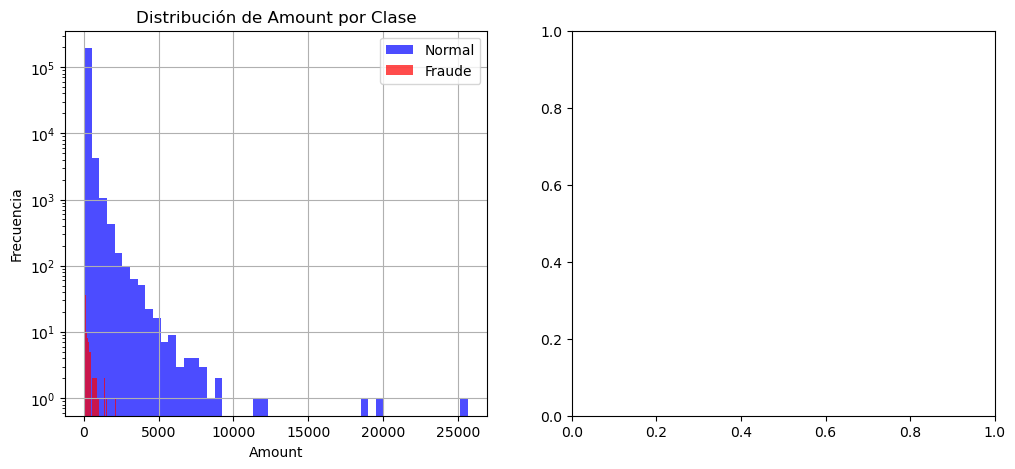

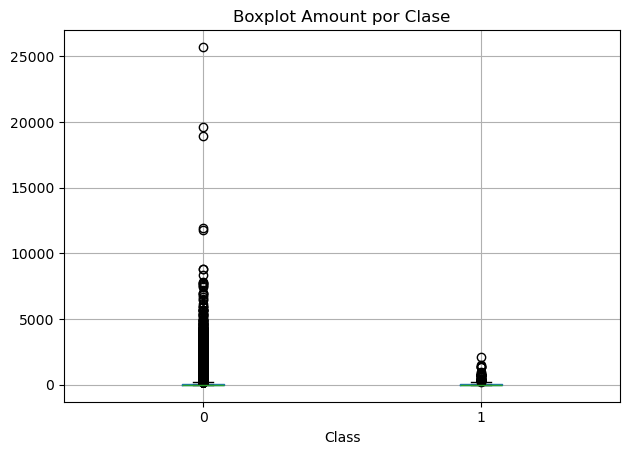

In [3]:
# ============================================================
# EDA - EXPLORATORY DATA ANALYSIS
# ============================================================

# Estadísticas descriptivas
print("--- ESTADÍSTICAS DESCRIPTIVAS ---")
train_df.describe().show()

# Verificar valores nulos
print("\n--- VALORES NULOS ---")
from pyspark.sql.functions import isnan, when, count, col

null_counts = train_df.select([
    count(when(col(c).isNull() | isnan(c), c)).alias(c) 
    for c in train_df.columns
])
null_counts.show()

# Distribución de Amount por clase
pandas_train = train_df.select("Amount", "Class").toPandas()

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
pandas_train[pandas_train["Class"] == 0]["Amount"].hist(bins=50, alpha=0.7, label="Normal", color="blue")
pandas_train[pandas_train["Class"] == 1]["Amount"].hist(bins=50, alpha=0.7, label="Fraude", color="red")
plt.xlabel("Amount")
plt.ylabel("Frecuencia")
plt.title("Distribución de Amount por Clase")
plt.legend()
plt.yscale("log")

plt.subplot(1, 2, 2)
pandas_train.boxplot(column="Amount", by="Class")
plt.title("Boxplot Amount por Clase")
plt.suptitle("")

plt.tight_layout()
plt.show()

In [4]:
# ============================================================
# PREPARACIÓN DE DATOS
# ============================================================

# Definir columnas de features
feature_cols = ["Time"] + [f"V{i}" for i in range(1, 29)] + ["Amount"]

# VectorAssembler
assembler = VectorAssembler(inputCols=feature_cols, outputCol="features_raw")
train_assembled = assembler.transform(train_df)

# StandardScaler
scaler = StandardScaler(
    inputCol="features_raw", 
    outputCol="features", 
    withStd=True, 
    withMean=True
)
scaler_model = scaler.fit(train_assembled)
train_scaled = scaler_model.transform(train_assembled)

# DIVISIÓN TRAIN/VALIDATION CON TU SEMILLA
train_split, val_split = train_scaled.randomSplit([0.8, 0.2], seed=SEMILLA)

# Reportar tamaños (Pregunta 2 del parcial)
print("=" * 50)
print("RESPUESTA PREGUNTA 2:")
print(f"a) Mi semilla es: {SEMILLA}")

train_count = train_split.count()
val_count = val_split.count()
print(f"b) Train interno: {train_count} filas")
print(f"   Validation: {val_count} filas")

# Contar fraudes en cada conjunto
train_fraudes = train_split.filter(col("Class") == 1).count()
val_fraudes = val_split.filter(col("Class") == 1).count()
print(f"c) Fraudes en train interno: {train_fraudes}")
print(f"   Fraudes en validation: {val_fraudes}")
print("=" * 50)

RESPUESTA PREGUNTA 2:
a) Mi semilla es: 7273
b) Train interno: 159437 filas
   Validation: 39927 filas
c) Fraudes en train interno: 273
   Fraudes en validation: 71


In [5]:
# ============================================================
# MANEJO DEL DESBALANCEO - Pesos de clase
# ============================================================

total = train_split.count()
fraud_count = train_split.filter(col("Class") == 1).count()
normal_count = train_split.filter(col("Class") == 0).count()

print(f"Total train interno: {total}")
print(f"Normales: {normal_count} ({normal_count/total*100:.2f}%)")
print(f"Fraudes: {fraud_count} ({fraud_count/total*100:.4f}%)")

# Calcular pesos
weight_fraud = total / (2 * fraud_count)
weight_normal = total / (2 * normal_count)

print(f"\nPeso fraude: {weight_fraud:.2f}")
print(f"Peso normal: {weight_normal:.2f}")

# Agregar columna de pesos
train_split = train_split.withColumn(
    "weight", 
    when(col("Class") == 1, weight_fraud).otherwise(weight_normal)
)

Total train interno: 159437
Normales: 159164 (99.83%)
Fraudes: 273 (0.1712%)

Peso fraude: 292.01
Peso normal: 0.50


In [6]:
# ============================================================
# MODELO 1: LOGISTIC REGRESSION (PySpark) - BASELINE
# ============================================================

print("=" * 60)
print("ENTRENANDO MODELO 1: LOGISTIC REGRESSION")
print("=" * 60)

# Definir evaluadores
evaluator_f1 = MulticlassClassificationEvaluator(
    labelCol="Class", 
    predictionCol="prediction", 
    metricName="f1"
)
evaluator_precision = MulticlassClassificationEvaluator(
    labelCol="Class", 
    predictionCol="prediction", 
    metricName="weightedPrecision"
)
evaluator_recall = MulticlassClassificationEvaluator(
    labelCol="Class", 
    predictionCol="prediction", 
    metricName="weightedRecall"
)
evaluator_auc = BinaryClassificationEvaluator(
    labelCol="Class", 
    rawPredictionCol="rawPrediction", 
    metricName="areaUnderROC"
)

# Entrenar Logistic Regression con pesos
lr = LogisticRegression(
    featuresCol="features",
    labelCol="Class",
    weightCol="weight",
    maxIter=10,
    regParam=0.01,
    elasticNetParam=0.0
)

lr_model = lr.fit(train_split)

# Predicciones en validation
lr_predictions = lr_model.transform(val_split)

# Calcular métricas
lr_f1 = evaluator_f1.evaluate(lr_predictions)
lr_precision = evaluator_precision.evaluate(lr_predictions)
lr_recall = evaluator_recall.evaluate(lr_predictions)
lr_auc = evaluator_auc.evaluate(lr_predictions)

print(f"\n--- MÉTRICAS LOGISTIC REGRESSION ---")
print(f"F1-Score:    {lr_f1:.4f}")
print(f"Precision:   {lr_precision:.4f}")
print(f"Recall:      {lr_recall:.4f}")
print(f"AUC:         {lr_auc:.4f}")

# Matriz de confusión
print(f"\n--- MATRIZ DE CONFUSIÓN ---")
lr_predictions.groupBy("Class", "prediction").count().show()

ENTRENANDO MODELO 1: LOGISTIC REGRESSION

--- MÉTRICAS LOGISTIC REGRESSION ---
F1-Score:    0.9936
Precision:   0.9983
Recall:      0.9899
AUC:         0.9735

--- MATRIZ DE CONFUSIÓN ---
+-----+----------+-----+
|Class|prediction|count|
+-----+----------+-----+
|    1|       0.0|    7|
|    0|       0.0|39460|
|    1|       1.0|   64|
|    0|       1.0|  396|
+-----+----------+-----+



In [7]:
# ============================================================
# MODELO 2: GBT - GRADIENT BOOSTED TREES (PySpark)
# ============================================================

print("=" * 60)
print("ENTRENANDO MODELO 2: GBT (GRADIENT BOOSTED TREES)")
print("=" * 60)

# NOTA: GBT en PySpark NO soporta weightCol directamente
# Usaremos subsampling para manejar el desbalanceo

gbt = GBTClassifier(
    featuresCol="features",
    labelCol="Class",
    maxIter=10,
    maxDepth=5,
    seed=SEMILLA,
    subsamplingRate=0.8
)

gbt_model = gbt.fit(train_split)

# Predicciones en validation
gbt_predictions = gbt_model.transform(val_split)

# Calcular métricas
gbt_f1 = evaluator_f1.evaluate(gbt_predictions)
gbt_precision = evaluator_precision.evaluate(gbt_predictions)
gbt_recall = evaluator_recall.evaluate(gbt_predictions)
gbt_auc = evaluator_auc.evaluate(gbt_predictions)

print(f"\n--- MÉTRICAS GBT ---")
print(f"F1-Score:    {gbt_f1:.4f}")
print(f"Precision:   {gbt_precision:.4f}")
print(f"Recall:      {gbt_recall:.4f}")
print(f"AUC:         {gbt_auc:.4f}")

# Matriz de confusión
print(f"\n--- MATRIZ DE CONFUSIÓN ---")
gbt_predictions.groupBy("Class", "prediction").count().show()

ENTRENANDO MODELO 2: GBT (GRADIENT BOOSTED TREES)

--- MÉTRICAS GBT ---
F1-Score:    0.9994
Precision:   0.9994
Recall:      0.9994
AUC:         0.9688

--- MATRIZ DE CONFUSIÓN ---
+-----+----------+-----+
|Class|prediction|count|
+-----+----------+-----+
|    1|       0.0|   19|
|    0|       0.0|39851|
|    1|       1.0|   52|
|    0|       1.0|    5|
+-----+----------+-----+



In [8]:
# ============================================================
# MODELO 3: ADABOOST (scikit-learn) - CON SAMPLING
# ============================================================

print("=" * 60)
print("ENTRENANDO MODELO 3: ADABOOST (scikit-learn)")
print("=" * 60)

# Convertir a Pandas con sampling para no saturar memoria
# Usamos solo una muestra estratificada del 30% para entrenar AdaBoost
print("Convirtiendo datos a Pandas (con sampling para memoria)...")

# Muestreo estratificado para mantener proporción de clases
train_sample = train_split.sampleBy("Class", fractions={0: 0.3, 1: 1.0}, seed=SEMILLA)
val_sample = val_split.sampleBy("Class", fractions={0: 0.5, 1: 1.0}, seed=SEMILLA)

print(f"Train sample: {train_sample.count()} filas")
print(f"Val sample: {val_sample.count()} filas")

train_pandas = train_sample.select(feature_cols + ["Class"]).toPandas()
val_pandas = val_sample.select(feature_cols + ["Class"]).toPandas()

X_train = train_pandas[feature_cols]
y_train = train_pandas["Class"]
X_val = val_pandas[feature_cols]
y_val = val_pandas["Class"]

print(f"X_train shape: {X_train.shape}")
print(f"X_val shape: {X_val.shape}")

ENTRENANDO MODELO 3: ADABOOST (scikit-learn)
Convirtiendo datos a Pandas (con sampling para memoria)...
Train sample: 47928 filas
Val sample: 19925 filas
X_train shape: (47928, 30)
X_val shape: (19925, 30)


In [9]:
# ============================================================
# BITÁCORA DE EXPERIMENTOS (Mínimo 5 experimentos)
# ============================================================

print("\n" + "=" * 60)
print("BITÁCORA DE EXPERIMENTOS - AdaBoost")
print("=" * 60)

# Experimento 1: Configuración base
print("\n--- Experimento 1: Base (n_estimators=50, learning_rate=1.0) ---")
ada_1 = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1, random_state=SEMILLA),
    n_estimators=50,
    learning_rate=1.0,
    algorithm='SAMME.R',
    random_state=SEMILLA
)
ada_1.fit(X_train, y_train)
pred_1 = ada_1.predict(X_val)
f1_1 = f1_score(y_val, pred_1)
print(f"F1: {f1_1:.4f}")

# Experimento 2: Aumentar n_estimators
print("\n--- Experimento 2: n_estimators=100 ---")
ada_2 = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1, random_state=SEMILLA),
    n_estimators=100,
    learning_rate=1.0,
    algorithm='SAMME.R',
    random_state=SEMILLA
)
ada_2.fit(X_train, y_train)
pred_2 = ada_2.predict(X_val)
f1_2 = f1_score(y_val, pred_2)
print(f"F1: {f1_2:.4f}")

# Experimento 3: Reducir learning_rate
print("\n--- Experimento 3: learning_rate=0.5 ---")
ada_3 = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1, random_state=SEMILLA),
    n_estimators=100,
    learning_rate=0.5,
    algorithm='SAMME.R',
    random_state=SEMILLA
)
ada_3.fit(X_train, y_train)
pred_3 = ada_3.predict(X_val)
f1_3 = f1_score(y_val, pred_3)
print(f"F1: {f1_3:.4f}")

# Experimento 4: Aumentar profundidad del árbol base
print("\n--- Experimento 4: max_depth=3 ---")
ada_4 = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=3, random_state=SEMILLA),
    n_estimators=100,
    learning_rate=0.5,
    algorithm='SAMME.R',
    random_state=SEMILLA
)
ada_4.fit(X_train, y_train)
pred_4 = ada_4.predict(X_val)
f1_4 = f1_score(y_val, pred_4)
print(f"F1: {f1_4:.4f}")

# Experimento 5: Más estimadores con learning rate ajustado
print("\n--- Experimento 5: n_estimators=200, learning_rate=0.3 ---")
ada_5 = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=3, random_state=SEMILLA),
    n_estimators=200,
    learning_rate=0.3,
    algorithm='SAMME.R',
    random_state=SEMILLA
)
ada_5.fit(X_train, y_train)
pred_5 = ada_5.predict(X_val)
f1_5 = f1_score(y_val, pred_5)
print(f"F1: {f1_5:.4f}")

# ============================================================
# SELECCIONAR MEJOR MODELO
# ============================================================

experimentos = {
    'Exp1_base': f1_1,
    'Exp2_n100': f1_2,
    'Exp3_lr05': f1_3,
    'Exp4_md3': f1_4,
    'Exp5_n200_lr03': f1_5
}

mejor_exp = max(experimentos, key=experimentos.get)
mejor_f1 = experimentos[mejor_exp]

print(f"\n{'=' * 60}")
print(f"MEJOR EXPERIMENTO: {mejor_exp} con F1 = {mejor_f1:.4f}")
print(f"{'=' * 60}")

# Entrenar modelo final con la mejor configuración
if mejor_exp == 'Exp1_base':
    ada_final = ada_1
    ada_predictions = pred_1
    ada_proba = ada_1.predict_proba(X_val)[:, 1]
elif mejor_exp == 'Exp2_n100':
    ada_final = ada_2
    ada_predictions = pred_2
    ada_proba = ada_2.predict_proba(X_val)[:, 1]
elif mejor_exp == 'Exp3_lr05':
    ada_final = ada_3
    ada_predictions = pred_3
    ada_proba = ada_3.predict_proba(X_val)[:, 1]
elif mejor_exp == 'Exp4_md3':
    ada_final = ada_4
    ada_predictions = pred_4
    ada_proba = ada_4.predict_proba(X_val)[:, 1]
else:
    ada_final = ada_5
    ada_predictions = pred_5
    ada_proba = ada_5.predict_proba(X_val)[:, 1]

# Calcular métricas finales
ada_f1 = f1_score(y_val, ada_predictions)
ada_precision = precision_score(y_val, ada_predictions)
ada_recall = recall_score(y_val, ada_predictions)
ada_auc = roc_auc_score(y_val, ada_proba)

print(f"\n--- MÉTRICAS FINALES ADABOOST ---")
print(f"F1-Score:    {ada_f1:.4f}")
print(f"Precision:   {ada_precision:.4f}")
print(f"Recall:      {ada_recall:.4f}")
print(f"AUC:         {ada_auc:.4f}")

# Matriz de confusión
print(f"\n--- MATRIZ DE CONFUSIÓN ---")
print(confusion_matrix(y_val, ada_predictions))
print(classification_report(y_val, ada_predictions))


BITÁCORA DE EXPERIMENTOS - AdaBoost

--- Experimento 1: Base (n_estimators=50, learning_rate=1.0) ---
F1: 0.7820

--- Experimento 2: n_estimators=100 ---
F1: 0.8029

--- Experimento 3: learning_rate=0.5 ---
F1: 0.8148

--- Experimento 4: max_depth=3 ---
F1: 0.8372

--- Experimento 5: n_estimators=200, learning_rate=0.3 ---
F1: 0.8636

MEJOR EXPERIMENTO: Exp5_n200_lr03 con F1 = 0.8636

--- MÉTRICAS FINALES ADABOOST ---
F1-Score:    0.8636
Precision:   0.9344
Recall:      0.8028
AUC:         0.9529

--- MATRIZ DE CONFUSIÓN ---
[[19850     4]
 [   14    57]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     19854
           1       0.93      0.80      0.86        71

    accuracy                           1.00     19925
   macro avg       0.97      0.90      0.93     19925
weighted avg       1.00      1.00      1.00     19925



In [10]:
# ============================================================
# PREGUNTA 3: ANÁLISIS DE ERRORES ESPECÍFICOS
# ============================================================

print("=" * 60)
print("PREGUNTA 3 - ANÁLISIS DE ERRORES (GBT - Mejor modelo)")
print("=" * 60)

# Obtener IDs del validation set
# NOTA: El dataset original tiene una columna 'id' o usamos el índice
# Verificar si hay columna id
print("Columnas en val_split:", val_split.columns)

# Si no hay columna 'id', creamos un índice
from pyspark.sql.functions import monotonically_increasing_id

val_with_id = val_split.withColumn("row_id", monotonically_increasing_id())

# Convertir predicciones a Pandas para análisis
val_pandas = val_with_id.select("row_id", "Class", "features").toPandas()
gbt_pred_pandas = gbt_predictions.select("prediction", "probability").toPandas()

# Unir
val_pandas["prediction"] = gbt_pred_pandas["prediction"].values
val_pandas["prob_fraude"] = [float(p[1]) for p in gbt_pred_pandas["probability"].values]

# a) Falsos Positivos con alta confianza (pred=1, real=0, prob>0.9)
fp_alta = val_pandas[
    (val_pandas["prediction"] == 1.0) & 
    (val_pandas["Class"] == 0) & 
    (val_pandas["prob_fraude"] > 0.9)
]

print(f"\na) Falsos Positivos con prob > 0.9: {len(fp_alta)} casos")
print("Top 3 IDs:")
if len(fp_alta) > 0:
    print(fp_alta.nsmallest(3, "prob_fraude")[["row_id", "prob_fraude"]])
else:
    print("No hay Falsos Positivos con probabilidad > 0.9")
    # Buscar con umbral más bajo
    fp_alta = val_pandas[
        (val_pandas["prediction"] == 1.0) & 
        (val_pandas["Class"] == 0)
    ]
    print(f"Falsos Positivos totales: {len(fp_alta)}")
    if len(fp_alta) > 0:
        print(fp_alta.nsmallest(3, "prob_fraude")[["row_id", "prob_fraude"]])

# b) Falsos Negativos (pred=0, real=1)
fn = val_pandas[
    (val_pandas["prediction"] == 0.0) & 
    (val_pandas["Class"] == 1)
]

print(f"\nb) Falsos Negativos totales: {len(fn)}")
print("Top 3 IDs (fraudes no detectados):")
if len(fn) > 0:
    print(fn.nlargest(3, "prob_fraude")[["row_id", "prob_fraude"]])

# c) Análisis de features para uno de los casos
print(f"\nc) ANÁLISIS DE FEATURES DE UN CASO ERRÓNEO")
if len(fp_alta) > 0:
    caso_id = fp_alta.iloc[0]["row_id"]
    caso = val_pandas[val_pandas["row_id"] == caso_id]
    print(f"Caso ID: {caso_id} (Falso Positivo)")
else:
    caso_id = fn.iloc[0]["row_id"]
    caso = val_pandas[val_pandas["row_id"] == caso_id]
    print(f"Caso ID: {caso_id} (Falso Negativo)")

print(f"Probabilidad predicha: {caso['prob_fraude'].values[0]:.4f}")
print(f"Clase real: {caso['Class'].values[0]}")

# Obtener features del caso (necesitamos reconstruir)
caso_features = val_split.filter(col("Class") == caso["Class"].values[0]).limit(1).toPandas()
print(f"\nFeatures principales del caso:")
print(caso_features[["Time", "Amount", "V1", "V2", "V3", "V4", "V5"]])

PREGUNTA 3 - ANÁLISIS DE ERRORES (GBT - Mejor modelo)
Columnas en val_split: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class', 'features_raw', 'features']

a) Falsos Positivos con prob > 0.9: 0 casos
Top 3 IDs:
No hay Falsos Positivos con probabilidad > 0.9
Falsos Positivos totales: 5
           row_id  prob_fraude
477           477     0.789513
6119         6119     0.789513
30751  8589944756     0.835947

b) Falsos Negativos totales: 19
Top 3 IDs (fraudes no detectados):
           row_id  prob_fraude
29043  8589943048     0.301372
34365  8589948370     0.236376
2835         2835     0.179203

c) ANÁLISIS DE FEATURES DE UN CASO ERRÓNEO
Caso ID: 477 (Falso Positivo)
Probabilidad predicha: 0.7895
Clase real: 0

Features principales del caso:
   Time  Amount        V1        V2       V3        V4        V5
0  12.0    58.8 -2

In [13]:
# ============================================================
# GENERAR SUBMISSION.CSV CON EL MEJOR MODELO (GBT) - CORREGIDO
# ============================================================

print("=" * 60)
print("GENERANDO SUBMISSION.CSV")
print("=" * 60)

# Verificar cuántas filas tiene realmente test_df
print(f"Filas en test_df: {test_df.count()}")
print(f"Filas en test original según instrucciones: 42720")

# Preparar test set
test_assembled = assembler.transform(test_df)
test_scaled = scaler_model.transform(test_assembled)

# Predecir con GBT (mejor modelo)
test_predictions = gbt_model.transform(test_scaled)

# Extraer predicciones
submission_pandas = test_predictions.select("prediction").toPandas()
submission_pandas["prediction"] = submission_pandas["prediction"].astype(int)

print(f"Predicciones generadas: {len(submission_pandas)}")

# CORRECCIÓN: Si tiene 42721, probablemente el header cuenta como fila
# El sample_submission dice que deben ser 42720 filas + header
# Asumimos que la última fila es extra y la eliminamos
if len(submission_pandas) == 42721:
    print("⚠️  Se detectó 1 fila extra. Eliminando última fila...")
    submission_pandas = submission_pandas.iloc[:42720]

# Crear submission con IDs del 1 al 42720
submission = pd.DataFrame({
    'id': range(1, len(submission_pandas) + 1),
    'Class': submission_pandas["prediction"].values
})

# Verificar formato
print(f"\nFilas: {len(submission)}")
print(f"Columnas: {list(submission.columns)}")
print(f"\nPrimeras filas:")
print(submission.head(10))
print(f"\nÚltimas filas:")
print(submission.tail(10))
print(f"\nDistribución de predicciones:")
print(submission["Class"].value_counts())

# Guardar
submission.to_csv("/home/jovyan/work/submission.csv", index=False)
print(f"\n✅ submission.csv guardado correctamente")
print(f"Ubicación: /home/jovyan/work/submission.csv")

GENERANDO SUBMISSION.CSV
Filas en test_df: 42721
Filas en test original según instrucciones: 42720
Predicciones generadas: 42721
⚠️  Se detectó 1 fila extra. Eliminando última fila...

Filas: 42720
Columnas: ['id', 'Class']

Primeras filas:
   id  Class
0   1      0
1   2      0
2   3      0
3   4      0
4   5      0
5   6      0
6   7      0
7   8      0
8   9      0
9  10      0

Últimas filas:
          id  Class
42710  42711      0
42711  42712      0
42712  42713      0
42713  42714      0
42714  42715      0
42715  42716      0
42716  42717      0
42717  42718      0
42718  42719      0
42719  42720      0

Distribución de predicciones:
Class
0    42656
1       64
Name: count, dtype: int64

✅ submission.csv guardado correctamente
Ubicación: /home/jovyan/work/submission.csv
